# Every ball of the Indian Premier League, in plain SQL

**1,243 matches and 295,732 deliveries (2008 to 2026)**, one row per ball bowled, queried with SQL only. Cricket is a gift to SQL: batting averages need a join between balls faced and dismissals, bowling figures need `CASE` logic to decide which wickets belong to the bowler, and the game's phases (powerplay, middle overs, death overs) are a `CASE` over the over number. Window functions find each season's top performers (`ROW_NUMBER`), career totals (running `SUM() OVER`) and the batter-bowler duels that keep recurring. Python only runs the queries and draws the charts.

**Data:** ball-by-ball files from [Cricsheet](https://cricsheet.org/downloads/) (ODC-By licence). Run `python build_db.py` once to download the zip (about 7 MB) into a SQLite database, then point `IPL_DB` at that file.

**Reading the data.** Super-over deliveries (`innings` 3 and above) are excluded from every statistic, and venue names were cleaned in the build script (the same ground appears under several spellings). The match year is taken from the date, because the season labels in the source are inconsistent (`2007/08` for 2008, `2009/10` for 2010). A *legal ball* excludes wides and no-balls. Batters are not charged a ball faced for a wide, bowlers are not charged for byes or leg-byes, and run-outs and retirements are not credited to the bowler.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("IPL_DB", "ipl.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,deliveries,295732
1,matches,1243


## 1. How has the game changed, season by season?

Two innings per match are summed per ball: runs, legal balls and sixes. Grouping by year gives the run rate and the average first-innings score, and `LAG()` adds the change from the previous season.

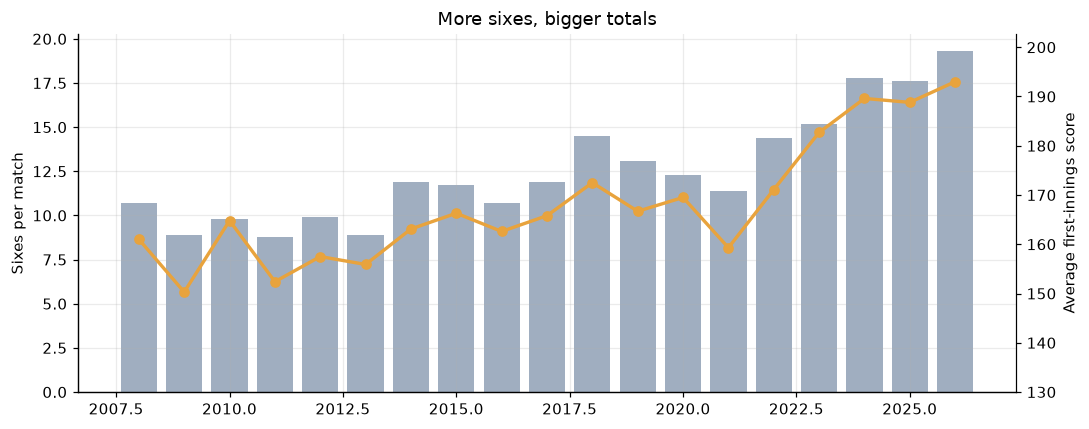

,year,matches,avg_first_innings,runs_per_over,sixes_per_match,change_in_first_innings
13,2021,60,159.3,8.05,11.4,-10.2
14,2022,74,171.1,8.54,14.4,11.8
15,2023,74,182.7,8.99,15.2,11.6
16,2024,71,189.6,9.56,17.8,6.9
17,2025,74,188.8,9.63,17.6,-0.8
18,2026,74,193.0,9.88,19.3,4.2


In [3]:
seasons = q("""
WITH innings AS (
    SELECT d.match_id, d.innings,
           SUM(d.runs_off_bat + d.extras)                           AS runs,
           SUM(CASE WHEN d.wides = 0 AND d.noballs = 0 THEN 1 ELSE 0 END) AS legal_balls,
           SUM(d.runs_off_bat = 6)                                  AS sixes
    FROM deliveries d
    WHERE d.innings <= 2
    GROUP BY d.match_id, d.innings
),
yearly AS (
    SELECT CAST(substr(m.date, 1, 4) AS INT)                                                  AS year,
           COUNT(DISTINCT m.match_id)                              AS matches,
           ROUND(AVG(CASE WHEN i.innings = 1 THEN i.runs END), 1)  AS avg_first_innings,
           ROUND(6.0 * SUM(i.runs) / SUM(i.legal_balls), 2)        AS runs_per_over,
           ROUND(1.0 * SUM(i.sixes) / COUNT(DISTINCT m.match_id), 1) AS sixes_per_match
    FROM innings i
    JOIN matches m USING (match_id)
    GROUP BY year
)
SELECT year, matches, avg_first_innings, runs_per_over, sixes_per_match,
       ROUND(avg_first_innings - LAG(avg_first_innings) OVER (ORDER BY year), 1) AS change_in_first_innings
FROM yearly
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(seasons.year, seasons.sixes_per_match, color=GREY, label="Sixes per match")
ax.set_ylabel("Sixes per match")
ax2 = ax.twinx()
ax2.plot(seasons.year, seasons.avg_first_innings, color=AMBER, marker="o", lw=2.2, label="Average first-innings score")
ax2.set_ylabel("Average first-innings score")
ax2.set_ylim(130, seasons.avg_first_innings.max() * 1.05)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("More sixes, bigger totals")
fig.tight_layout()
plt.show()
seasons.tail(6)

## 2. Who has scored the most runs?

Batting figures need two aggregations joined together: runs and balls faced per batter (the `striker`), and the number of times each batter was dismissed (`player_dismissed`). The average is runs per dismissal and the strike rate is runs per 100 balls faced.

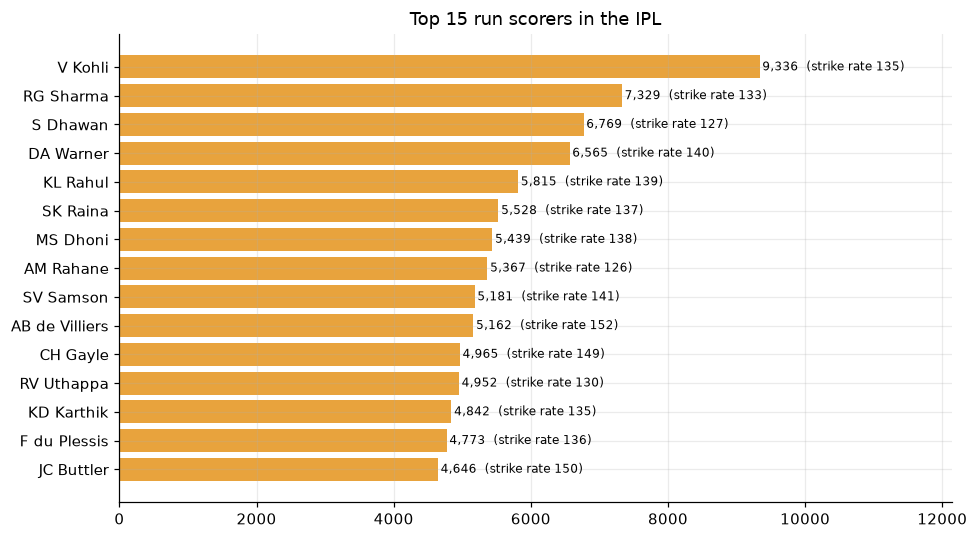

,rank,player,matches,runs,average,strike_rate,fours,sixes
0,1,V Kohli,275,9336,40.4,134.8,845,317
1,2,RG Sharma,275,7329,29.9,132.9,661,324
2,3,S Dhawan,221,6769,35.3,127.1,768,153
3,4,DA Warner,184,6565,40.5,139.8,663,236
4,5,KL Rahul,149,5815,46.2,139.1,508,239
5,6,SK Raina,200,5528,32.5,136.7,506,203
6,7,MS Dhoni,241,5439,38.3,137.5,375,264
7,8,AM Rahane,197,5367,30.2,125.6,540,141
8,9,SV Samson,185,5181,31.8,141.1,432,243
9,10,AB de Villiers,170,5162,39.7,151.7,413,251


In [4]:
batters = q("""
WITH batting AS (
    SELECT striker                                         AS player,
           COUNT(DISTINCT match_id)                        AS matches,
           SUM(runs_off_bat)                               AS runs,
           SUM(CASE WHEN wides = 0 THEN 1 ELSE 0 END)      AS balls_faced,
           SUM(runs_off_bat = 4)                           AS fours,
           SUM(runs_off_bat = 6)                           AS sixes
    FROM deliveries
    WHERE innings <= 2
    GROUP BY striker
),
outs AS (
    SELECT player_dismissed AS player, COUNT(*) AS dismissals
    FROM deliveries
    WHERE innings <= 2 AND wicket_type IS NOT NULL AND wicket_type NOT IN ('retired hurt', 'retired out')
    GROUP BY player_dismissed
)
SELECT RANK() OVER (ORDER BY b.runs DESC)                 AS rank,
       b.player, b.matches, b.runs,
       ROUND(1.0 * b.runs / NULLIF(o.dismissals, 0), 1)   AS average,
       ROUND(100.0 * b.runs / b.balls_faced, 1)           AS strike_rate,
       b.fours, b.sixes
FROM batting b
LEFT JOIN outs o USING (player)
ORDER BY b.runs DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(batters.player[::-1], batters.runs[::-1], color=AMBER)
for y, (r, sr) in enumerate(zip(batters.runs[::-1], batters.strike_rate[::-1])):
    ax.text(r + 40, y, f"{r:,}  (strike rate {sr:.0f})", va="center", fontsize=8)
ax.set_xlim(0, batters.runs.max() * 1.3)
ax.set_title("Top 15 run scorers in the IPL")
fig.tight_layout()
plt.show()
batters

## 3. Who has taken the most wickets, and at what cost?

A wicket belongs to the bowler only for certain dismissals (`CASE`): not run-outs or retirements. The bowler is charged runs off the bat, wides and no-balls but not byes or leg-byes. Economy is runs per six legal balls. Only bowlers who have bowled at least 1,000 legal balls (about 167 overs) are ranked.

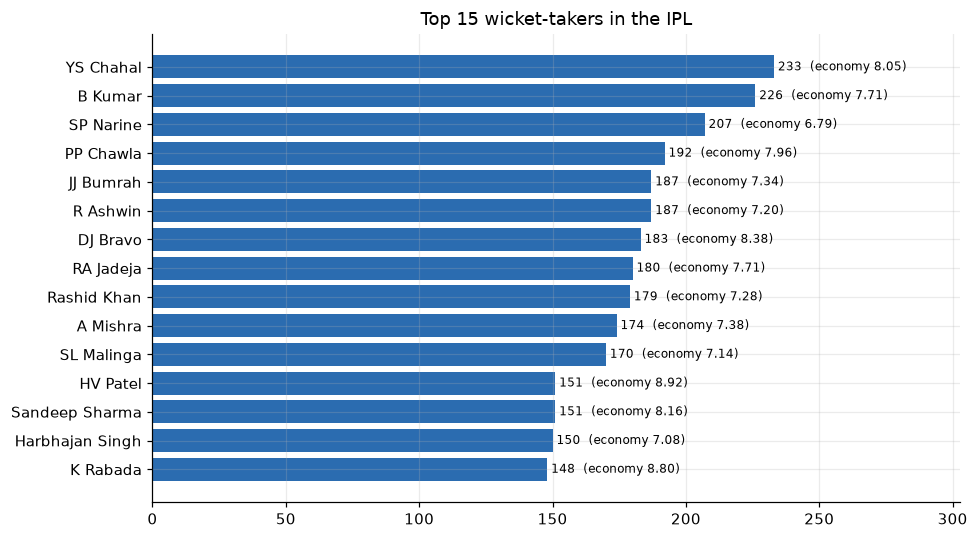

,rank,bowler,matches,wickets,economy,average,balls_per_wicket
0,1,YS Chahal,184,233,8.05,23.2,17.3
1,2,B Kumar,206,226,7.71,26.2,20.4
2,3,SP Narine,200,207,6.79,25.4,22.5
3,4,PP Chawla,191,192,7.96,26.6,20.1
4,5,JJ Bumrah,158,187,7.34,23.7,19.4
5,5,R Ashwin,217,187,7.20,30.2,25.2
6,7,DJ Bravo,158,183,8.38,23.8,17.0
7,8,RA Jadeja,237,180,7.71,30.4,23.6
8,9,Rashid Khan,153,179,7.28,23.9,19.7
9,10,A Mishra,162,174,7.38,23.8,19.4


In [5]:
bowlers = q("""
WITH bowling AS (
    SELECT bowler,
           COUNT(DISTINCT match_id)                                           AS matches,
           SUM(CASE WHEN wides = 0 AND noballs = 0 THEN 1 ELSE 0 END)         AS legal_balls,
           SUM(runs_off_bat + wides + noballs)                                AS runs_conceded,
           SUM(CASE WHEN wicket_type IN ('bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket') THEN 1 ELSE 0 END)   AS wickets
    FROM deliveries
    WHERE innings <= 2
    GROUP BY bowler
    HAVING legal_balls >= 1000
)
SELECT RANK() OVER (ORDER BY wickets DESC)           AS rank,
       bowler, matches, wickets,
       ROUND(6.0 * runs_conceded / legal_balls, 2)   AS economy,
       ROUND(1.0 * runs_conceded / wickets, 1)       AS average,
       ROUND(1.0 * legal_balls / wickets, 1)         AS balls_per_wicket
FROM bowling
ORDER BY wickets DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(bowlers.bowler[::-1], bowlers.wickets[::-1], color=BLUE)
for y, (w, e) in enumerate(zip(bowlers.wickets[::-1], bowlers.economy[::-1])):
    ax.text(w + 1.5, y, f"{w}  (economy {e:.2f})", va="center", fontsize=8)
ax.set_xlim(0, bowlers.wickets.max() * 1.3)
ax.set_title("Top 15 wicket-takers in the IPL")
fig.tight_layout()
plt.show()
bowlers

## 4. How do the powerplay, the middle overs and the death overs differ?

A `CASE` on the over number splits every ball into a phase. Runs per over and wickets per innings are then computed per season and phase.

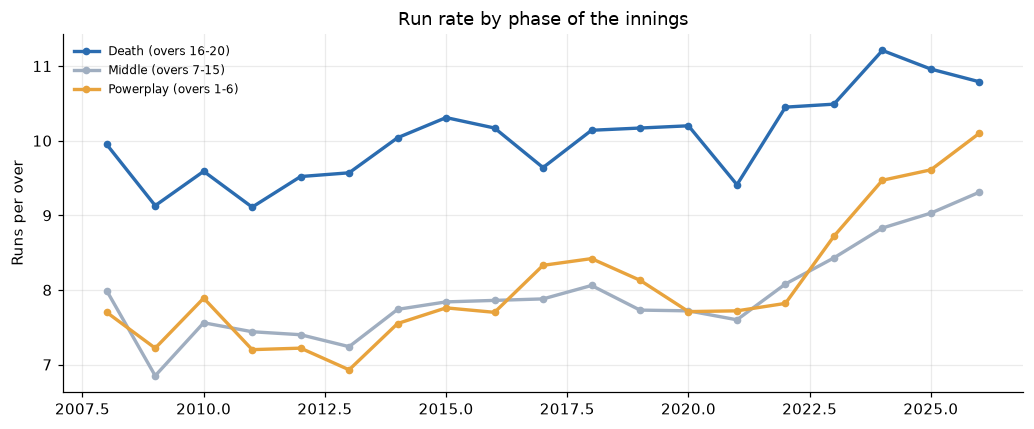

,year,phase,runs_per_over,wickets_per_innings
54,2026,Death (overs 16-20),10.79,1.95
55,2026,Middle (overs 7-15),9.31,2.47
56,2026,Powerplay (overs 1-6),10.10,1.59


In [6]:
phases = q("""
WITH phased AS (
    SELECT CAST(substr(m.date, 1, 4) AS INT) AS year,
           CASE WHEN d.over < 6  THEN '1 Powerplay (overs 1-6)'
                WHEN d.over < 15 THEN '2 Middle (overs 7-15)'
                ELSE                  '3 Death (overs 16-20)' END                  AS phase,
           d.match_id,
           d.runs_off_bat + d.extras                                               AS runs,
           CASE WHEN d.wides = 0 AND d.noballs = 0 THEN 1 ELSE 0 END               AS legal,
           CASE WHEN d.wicket_type IS NOT NULL
                 AND d.wicket_type NOT IN ('retired hurt', 'retired out') THEN 1 ELSE 0 END AS wicket
    FROM deliveries d
    JOIN matches m USING (match_id)
    WHERE d.innings <= 2
)
SELECT year,
       substr(phase, 3)                                                     AS phase,
       ROUND(6.0 * SUM(runs) / SUM(legal), 2)                               AS runs_per_over,
       ROUND(1.0 * SUM(wicket) / (2 * COUNT(DISTINCT match_id)), 2)         AS wickets_per_innings
FROM phased
GROUP BY year, phase
ORDER BY year, phase
""")

wide = phases.pivot(index="year", columns="phase", values="runs_per_over")
fig, ax = plt.subplots(figsize=(9.5, 4))
for col, color in zip(wide.columns, [BLUE, GREY, AMBER]):
    ax.plot(wide.index, wide[col], marker="o", ms=4, lw=2.2, color=color, label=col)
ax.set_ylabel("Runs per over")
ax.set_title("Run rate by phase of the innings")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
phases[phases.year == phases.year.max()]

## 5. Is it easier to chase, and does it depend on the ground?

Join the match result to the team that batted second (taken from the second innings of the ball-by-ball table) and count how often it won, ground by ground.

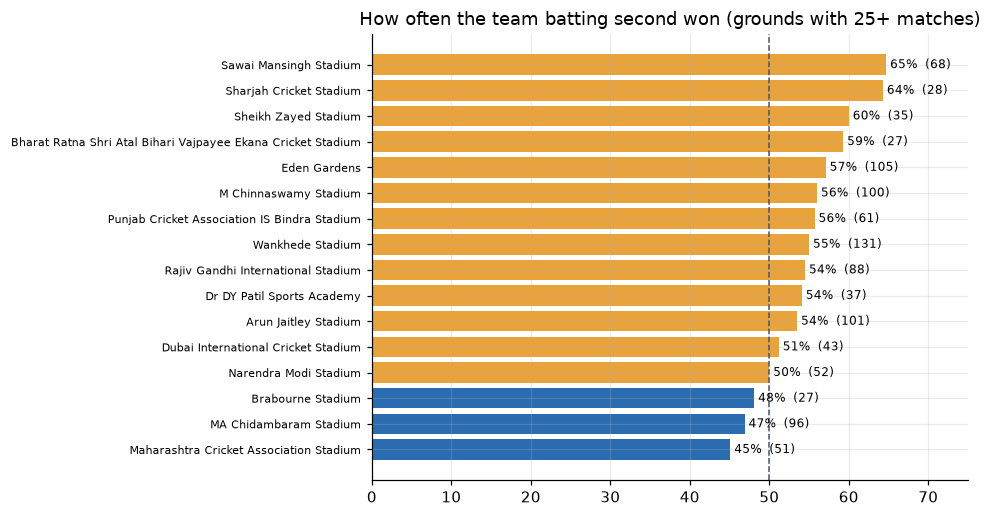

matches                1050
won_by_chasing_side     572
dtype: int64

In [7]:
chase = q("""
WITH second AS (
    SELECT DISTINCT match_id, batting_team AS chasing_team
    FROM deliveries
    WHERE innings = 2
)
SELECT m.venue,
       COUNT(*)                                                       AS matches,
       SUM(m.winner = s.chasing_team)                                 AS won_by_chasing_side,
       ROUND(100.0 * SUM(m.winner = s.chasing_team) / COUNT(*), 1)    AS chasing_win_pct
FROM matches m
JOIN second s USING (match_id)
WHERE m.winner IS NOT NULL
GROUP BY m.venue
HAVING matches >= 25
ORDER BY chasing_win_pct DESC
""")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(chase.venue[::-1], chase.chasing_win_pct[::-1], color=[AMBER if v >= 50 else BLUE for v in chase.chasing_win_pct[::-1]])
ax.axvline(50, color="#4a5568", lw=1, ls="--")
for y, (v, n) in enumerate(zip(chase.chasing_win_pct[::-1], chase.matches[::-1])):
    ax.text(v + 0.5, y, f"{v:.0f}%  ({n})", va="center", fontsize=8)
ax.set_xlim(0, 75)
ax.set_title("How often the team batting second won (grounds with 25+ matches)")
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
plt.show()
chase.agg({"matches": "sum", "won_by_chasing_side": "sum"})

## 6. Does winning the toss matter?

Averaging 0/1 flags per year gives the share of captains who chose to field and the share of toss winners who went on to win the match (matches without a result are left out of the second figure).

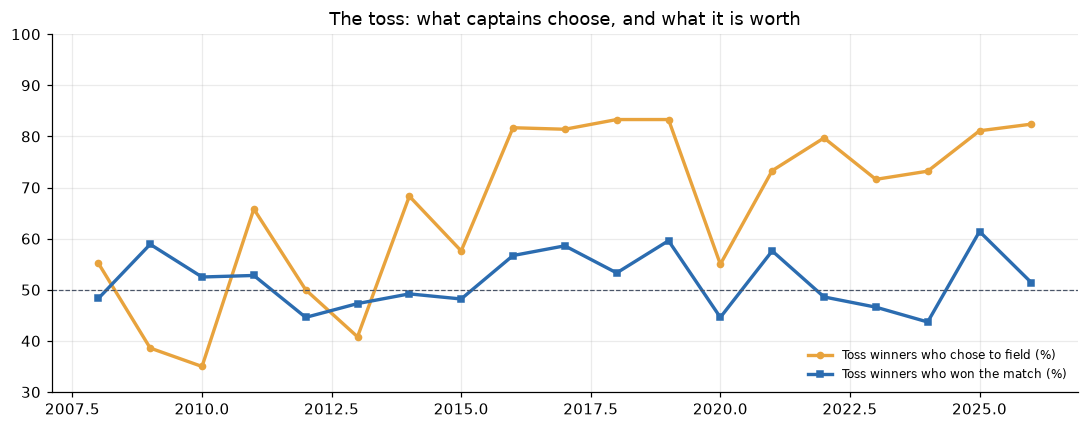

,matches,chose_to_field_pct,toss_winner_won_pct
mean,65.4,66.2,51.8
min,57.0,35.0,43.7
max,76.0,83.3,61.4


In [8]:
toss = q("""
SELECT CAST(substr(date, 1, 4) AS INT)                                              AS year,
       COUNT(*)                                                                     AS matches,
       ROUND(100.0 * AVG(toss_decision = 'field'), 1)                               AS chose_to_field_pct,
       ROUND(100.0 * AVG(CASE WHEN winner IS NOT NULL THEN toss_winner = winner END), 1) AS toss_winner_won_pct
FROM matches
GROUP BY year
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(toss.year, toss.chose_to_field_pct, marker="o", ms=4, lw=2.2, color=AMBER, label="Toss winners who chose to field (%)")
ax.plot(toss.year, toss.toss_winner_won_pct, marker="s", ms=4, lw=2.2, color=BLUE, label="Toss winners who won the match (%)")
ax.axhline(50, color="#4a5568", lw=0.8, ls="--")
ax.set_ylim(30, 100)
ax.set_title("The toss: what captains choose, and what it is worth")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()
toss[["matches", "chose_to_field_pct", "toss_winner_won_pct"]].describe().round(1).loc[["mean", "min", "max"]]

## 7. Who won the orange and purple caps each season?

`ROW_NUMBER() OVER (PARTITION BY year ORDER BY runs DESC)` numbers the batters inside each season and keeps the first. The same trick finds each season's leading wicket-taker, and the two ranked tables are joined on the year.

In [9]:
caps = q("""
WITH runs AS (
    SELECT CAST(substr(m.date, 1, 4) AS INT) AS year, d.striker AS player, SUM(d.runs_off_bat) AS runs
    FROM deliveries d JOIN matches m USING (match_id)
    WHERE d.innings <= 2
    GROUP BY year, d.striker
),
top_bat AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY year ORDER BY runs DESC) AS rn FROM runs
),
wickets AS (
    SELECT CAST(substr(m.date, 1, 4) AS INT) AS year, d.bowler AS player,
           SUM(CASE WHEN d.wicket_type IN ('bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket') THEN 1 ELSE 0 END) AS wickets
    FROM deliveries d JOIN matches m USING (match_id)
    WHERE d.innings <= 2
    GROUP BY year, d.bowler
),
top_bowl AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY year ORDER BY wickets DESC) AS rn FROM wickets
)
SELECT b.year,
       b.player AS top_run_scorer, b.runs,
       w.player AS top_wicket_taker, w.wickets
FROM top_bat b
JOIN top_bowl w ON w.year = b.year AND w.rn = 1
WHERE b.rn = 1
ORDER BY b.year
""")

caps

,year,top_run_scorer,runs,top_wicket_taker,wickets
0,2008,SE Marsh,616,Sohail Tanvir,22
1,2009,ML Hayden,572,RP Singh,23
2,2010,SR Tendulkar,618,PP Ojha,21
3,2011,CH Gayle,608,SL Malinga,28
4,2012,CH Gayle,733,M Morkel,25
5,2013,MEK Hussey,733,DJ Bravo,32
6,2014,RV Uthappa,660,MM Sharma,23
7,2015,DA Warner,562,DJ Bravo,26
8,2016,V Kohli,973,B Kumar,23
9,2017,DA Warner,641,B Kumar,26


## 8. Which bowlers keep getting the same batter out?

Grouping by the pair (batter, bowler) turns the ball-by-ball table into head-to-head records. A dismissal counts when the bowler is credited with the wicket and the dismissed player is the batter facing. Only pairs with at least 40 balls are considered.

In [10]:
duels = q("""
SELECT RANK() OVER (ORDER BY SUM(CASE WHEN player_dismissed = striker AND wicket_type IN ('bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket') THEN 1 ELSE 0 END) DESC,
                             SUM(CASE WHEN wides = 0 THEN 1 ELSE 0 END) DESC)         AS rank,
       striker                                                                        AS batter,
       bowler,
       SUM(CASE WHEN wides = 0 THEN 1 ELSE 0 END)                                     AS balls,
       SUM(runs_off_bat)                                                              AS runs,
       SUM(CASE WHEN player_dismissed = striker AND wicket_type IN ('bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket') THEN 1 ELSE 0 END) AS dismissals,
       ROUND(100.0 * SUM(runs_off_bat) / SUM(CASE WHEN wides = 0 THEN 1 ELSE 0 END), 0) AS strike_rate
FROM deliveries
WHERE innings <= 2
GROUP BY striker, bowler
HAVING balls >= 40
ORDER BY dismissals DESC, balls DESC
LIMIT 12
""")

duels

,rank,batter,bowler,balls,runs,dismissals,strike_rate
0,1,RG Sharma,SP Narine,137,145,8,106.0
1,2,AM Rahane,B Kumar,124,109,7,88.0
2,3,RV Uthappa,R Ashwin,94,123,7,131.0
3,4,V Kohli,Sandeep Sharma,91,141,7,155.0
4,4,RG Sharma,A Mishra,91,87,7,96.0
5,6,AT Rayudu,MM Sharma,49,71,7,145.0
6,7,RR Pant,JJ Bumrah,46,55,7,120.0
7,7,MA Agarwal,YS Chahal,46,72,7,157.0
8,9,MS Dhoni,Z Khan,42,74,7,176.0
9,10,MS Dhoni,PP Ojha,96,98,6,102.0


## 9. How do the great careers build up?

A running `SUM(runs) OVER (PARTITION BY player ORDER BY year)` turns each season's runs into career totals, for the five leading run scorers.

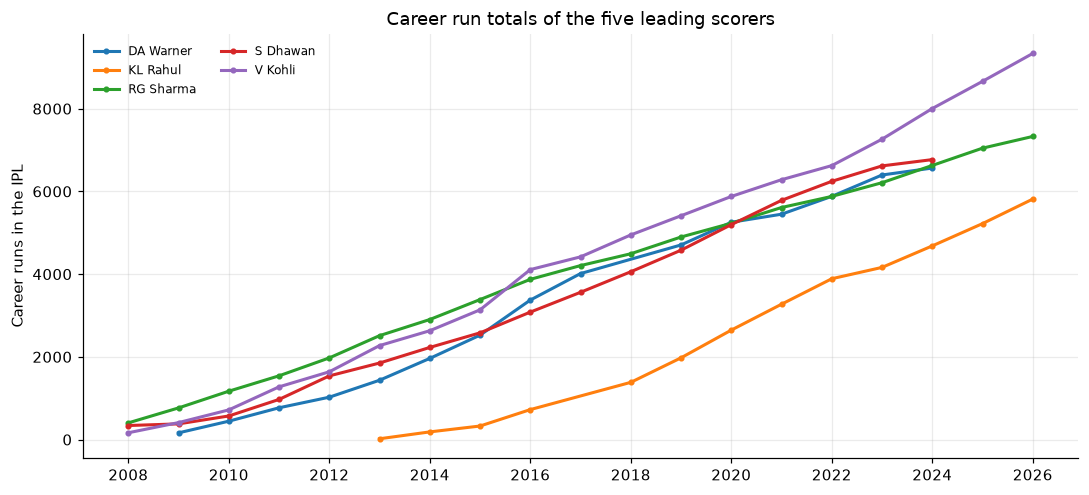

,player,year,runs,career_runs
82,V Kohli,2026,675,9336
46,RG Sharma,2026,283,7329
63,S Dhawan,2024,152,6769
14,DA Warner,2024,168,6565
27,KL Rahul,2026,593,5815


In [11]:
career = q("""
WITH yearly AS (
    SELECT d.striker AS player, CAST(substr(m.date, 1, 4) AS INT) AS year, SUM(d.runs_off_bat) AS runs
    FROM deliveries d JOIN matches m USING (match_id)
    WHERE d.innings <= 2
    GROUP BY d.striker, year
),
top5 AS (
    SELECT striker FROM deliveries WHERE innings <= 2 GROUP BY striker ORDER BY SUM(runs_off_bat) DESC LIMIT 5
)
SELECT player, year, runs,
       SUM(runs) OVER (PARTITION BY player ORDER BY year) AS career_runs
FROM yearly
WHERE player IN (SELECT striker FROM top5)
ORDER BY player, year
""")

fig, ax = plt.subplots(figsize=(10, 4.6))
for player, g in career.groupby("player"):
    ax.plot(g.year, g.career_runs, marker="o", ms=3, lw=2, label=player)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylabel("Career runs in the IPL")
ax.set_title("Career run totals of the five leading scorers")
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
career.sort_values("career_runs", ascending=False).groupby("player").head(1).sort_values("career_runs", ascending=False)

## What the queries say

- **The game has got much faster.** The average first-innings score rose from 161 in 2008 to 193 in 2026, and almost all of that rise came in the last five seasons (159 in 2021, 171 in 2022, 183 in 2023, 190 in 2024). Sixes per match went from 10.7 to 19.3 over the same period, and the run rate from 8.31 to 9.88 runs per over.
- **The powerplay changed most.** Runs per over in overs 1-6 rose from 7.70 in 2008 to 10.10 in 2026, which is now the same pace as the death overs (10.79), while the middle overs went from 7.99 to 9.31. The old pattern of a slow start and a fast finish has almost disappeared.
- **Kohli leads the run charts by a distance.** V Kohli has 9,336 runs, 2,000 more than Rohit Sharma (7,329) and Dhawan (6,769), at an average of 40.4. His 973 runs in 2016 is the highest season total in the table of cap winners (the next highest is 890, Shubman Gill in 2023). Warner has the best strike rate of the top five (139.8), and Gayle hit the most sixes of anyone in the top twelve (357).
- **Wicket-takers are led by spinners and one swing bowler.** Chahal (233), Bhuvneshwar Kumar (226) and Narine (207) head the list. Narine's economy of 6.79 is the best of the top twelve, while Malinga has the lowest average (19.8 runs per wicket) with fewer wickets (170), because he played fewer matches.
- **Chasing is slightly easier, but it depends on the ground.** Across grounds with 25 or more matches, the chasing side wins between 45% (Maharashtra Cricket Association Stadium, Pune) and 65% (Sawai Mansingh Stadium, Jaipur). Chennai's Chepauk ground is below 50% (46.9% in 96 matches), but the differences between most grounds are small compared with what 30 to 100 matches can produce by chance.
- **The toss is worth almost nothing.** Toss winners won 628 of 1,218 matches with a result (51.6%), and two thirds of captains (66%) chose to field. The yearly figure swings between 44% and 61%, but with 60 to 74 matches a year chance alone moves it by several points, so no single season shows a toss effect.
- **Some pairings are one-sided.** Rohit Sharma was dismissed eight times in 137 balls by Narine, and Kohli seven times by Sandeep Sharma, even though he scored at a strike rate of 155 against him. These are small samples (45 to 140 balls), so they describe history rather than predict anything.

**Limits.** Super overs are excluded. Run-outs and retirements are not credited to the bowler. Venue names were merged by hand (for example Feroz Shah Kotla and Arun Jaitley Stadium are the same ground), and a few aliases may still be missing. The 2026 season is included in full as it appears in the source files.
